In [2]:
from scipy.special import roots_jacobi, eval_jacobi
import pandas as pd
import numpy as np
import uxarray as ux
import xarray as xr

In [3]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [4]:
# Note: For ne15, use coeff = 1e7 / (6.371e6 ** 4) 

In [5]:
grid_file = ux.open_grid('/home/hsingh/Downloads/TEMPEST_ne15.g')
node_connect = grid_file.face_node_connectivity

In [6]:
npts = 4
p_order = npts - 1
xinterior, w = roots_jacobi(p_order - 1,1,1) # returns interior GLL nodes from range -1 and 1
GLL_points = np.pad(xinterior, (1, 1), 'constant', constant_values=(-1, 1))

ref_coords = np.meshgrid(GLL_points, GLL_points[::-1])

### Define Derivative Operator:

In [7]:
# Assumes array_in has dims ('x2', 'y2'):
def pd_y(array_in, xr_D):
    return(xr.apply_ufunc(np.matmul,
           xr_D, array_in,
           input_core_dims=[['x2', 'y2'], ['x2', 'y2']],
           output_core_dims=[['x2', 'y2']],
           vectorize=True,
           dask="parallelized",
           output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype]))

In [8]:
# Assumes array_in has dims ('n_face', 'x2', 'y2'):
def pd_x(array_in, xr_D):
    array_out = xr.apply_ufunc(np.matmul,
                   xr_D, array_in.transpose('n_face', 'y2', 'x2'),
                   input_core_dims=[['x2', 'y2'], ['y2', 'x2']],
                   output_core_dims=[['y2', 'x2']],
                   vectorize=True,
                   dask="parallelized",
                   output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
    
    # Return a transposed array:
    return(array_out.transpose('n_face', 'x2', 'y2'))

In [9]:
def vandermonde(npts_values, return_type):
    # For the monomial basis: 
    if return_type == 'Monomial':
        return(np.vander(npts_values, increasing = True))
    elif return_type == 'Legendre':
        return(np.polynomial.legendre.legvander(npts_values, len(npts_values) - 1))

In [10]:
def Ld_vandermonde(npts_values): 
    
    LP = np.polynomial.legendre
    v_matrix = np.polynomial.legendre.legvander(npts_values, len(npts_values)-1)
    d_v_matrix = np.zeros_like(v_matrix)

    for i in range(len(npts_values)):
        # Coefficients for the i-th Legendre polynomial (e.g., [0, 0, 1] for P_2)
        coeffs = np.zeros(len(npts_values))
        coeffs[i] = 1

        # Compute the derivative of the i-th Legendre polynomial
        deriv_coeffs = LP.legder(coeffs, m=1) # m=1 for first derivative

        # Evaluate the derivative at the points x
        d_v_matrix[:, i] = LP.legval(npts_values, deriv_coeffs)
        
    return(d_v_matrix)

In [11]:
def return_D(V1, V2):
    return(np.matmul(V2, np.linalg.inv(V1)))

In [12]:
V1 = vandermonde(GLL_points, 'Legendre')
V2 = Ld_vandermonde(GLL_points)
D = return_D(V1, V2)

In [13]:
xr_D = xr.DataArray(data = D, coords = {'x2' : np.arange(npts),
                                        'y2' : np.arange(npts)}, dims = ['x2', 'y2'])

### Map GLL points to the sphere:

In [14]:
# Returns Cartesian coordinates on the unit sphere: 
# Fills in starting with C1 from the bottom left, moves counterclockwise:
# GLL_point 12 is c1, GLL_point 15 is c2, GLL_point 3 is c3, GLL_point 0 is c4

def map_cartesian(grid_file, ref_coords, GLL_points):
    
    # Define arrays for corners in x_2, y_2:
    node_connect = grid_file.face_node_connectivity
    
    # Return the x, y, z comps of element corners of faces:
    node_x = grid_file.node_x.isel(n_node = node_connect)
    node_y = grid_file.node_y.isel(n_node = node_connect)
    node_z = grid_file.node_z.isel(n_node = node_connect)
    
    t1 = (1 - ref_coords[0]) * (1 - ref_coords[1])
    t2 = (1 + ref_coords[0]) * (1 - ref_coords[1])
    t3 = (1 + ref_coords[0]) * (1 + ref_coords[1])
    t4 = (1 - ref_coords[0]) * (1 + ref_coords[1])
    
    r1 = ((1/4) * (np.outer(node_x.isel(n_max_face_nodes = 0), t1.reshape(-1))
                   + np.outer(node_x.isel(n_max_face_nodes = 1), t2.reshape(-1)) 
                   + np.outer(node_x.isel(n_max_face_nodes = 2), t3.reshape(-1))
                   + np.outer(node_x.isel(n_max_face_nodes = 3), t4.reshape(-1)))).reshape(grid_file.n_face, len(GLL_points), len(GLL_points))
    
    r2 = ((1/4) * (np.outer(node_y.isel(n_max_face_nodes = 0), t1.reshape(-1))
                   + np.outer(node_y.isel(n_max_face_nodes = 1), t2.reshape(-1)) 
                   + np.outer(node_y.isel(n_max_face_nodes = 2), t3.reshape(-1))
                   + np.outer(node_y.isel(n_max_face_nodes = 3), t4.reshape(-1)))).reshape(grid_file.n_face, len(GLL_points), len(GLL_points))
    
    r3 = ((1/4) * (np.outer(node_z.isel(n_max_face_nodes = 0), t1.reshape(-1))
                   + np.outer(node_z.isel(n_max_face_nodes = 1), t2.reshape(-1)) 
                   + np.outer(node_z.isel(n_max_face_nodes = 2), t3.reshape(-1))
                   + np.outer(node_z.isel(n_max_face_nodes = 3), t4.reshape(-1)))).reshape(grid_file.n_face, len(GLL_points), len(GLL_points))
    
    r_vector = xr.Dataset(data_vars = {'x_comp' : (["n_face", "x2", "y2"], r1), 
                                       'y_comp' : (["n_face", "x2", "y2"], r2), 
                                       'z_comp' : (["n_face", "x2", "y2"], r3)},
                          coords = {'n_face' : (('n_face'), node_x.coords['n_face'].values),
                                    'GLL_points' : (('x2', 'y2'), np.arange(len(GLL_points) ** 2).reshape(len(GLL_points), len(GLL_points)))})
    
    r_norm = r_vector / np.sqrt((r_vector['x_comp'] ** 2) + (r_vector['y_comp'] ** 2) + (r_vector['z_comp'] ** 2))
    return(r_norm, np.sqrt((r_vector['x_comp'] ** 2) + (r_vector['y_comp'] ** 2) + (r_vector['z_comp'] ** 2)))
    # return(r_vector)


In [15]:
# Convert Cartesian coordinates on the unit sphere to lat/lon in radians: 

def map_spherical(input_array):
    
    # Note: lon returned from [-pi, pi], lat returned from [0, pi]
    lon_array = np.arctan2(input_array['y_comp'], input_array['x_comp'])
    lat_array = np.arccos(input_array['z_comp'])
    
    # Shift lon to [0, 2pi] and lat to [pi/2, -pi/2]:
    lat_shift = -(lat_array - (np.pi / 2))
    lon_shift = np.where(lon_array < 0, lon_array + (2 * np.pi), lon_array)
    
    return(xr.Dataset(data_vars = {'lat' : (["n_face", "x2", "y2"], lat_shift.data), 
                                   'lon' : (["n_face", "x2", "y2"], lon_shift.data)},
                      coords = {'n_face' : (('n_face'), input_array.coords['n_face'].values), 
                                'GLL_points' : (('x2', 'y2'), input_array.coords['GLL_points'].values)}))


In [16]:
GLL_test = map_cartesian(grid_file, ref_coords, GLL_points)[0]

In [17]:
map_spherical(map_cartesian(grid_file, ref_coords, GLL_points)[0])

<xarray.Dataset>
Dimensions:     (n_face: 1350, x2: 4, y2: 4)
Coordinates:
  * n_face      (n_face) int64 0 1 2 3 4 5 6 ... 1344 1345 1346 1347 1348 1349
    GLL_points  (x2, y2) int64 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
Dimensions without coordinates: x2, y2
Data variables:
    lat         (n_face, x2, y2) float64 -0.52 -0.532 -0.5507 ... 0.677 0.6606
    lon         (n_face, x2, y2) float64 5.498 5.526 5.573 ... 2.326 2.279 2.251

In [181]:
lat_array = map_spherical(map_cartesian(grid_file, ref_coords, GLL_points)[0])['lat']
lon_array = map_spherical(map_cartesian(grid_file, ref_coords, GLL_points)[0])['lon']

### Determine neighbors for DSS:

In [18]:
# Insert 2 additional data_vars, one for shared edges and one for shared corners:

def return_neighbors(grid_array, value_array, npts):
    # Preallocate arrays for corners and edges:
    edge_mapping = {(0, 1) : 'edge_1', (1, 2) : 'edge_2',
                    (2, 3) : 'edge_3', (0, 3) : 'edge_4'}
    GLL_index = np.array(([npts-1, 0], [npts-1, npts-1], [0, npts-1], [0, 0]))
    reverse_list = [('edge_2', 'edge_2'), ('edge_2', 'edge_3'), ('edge_1', 'edge_4'), 
                    ('edge_1', 'edge_1'), ('edge_3', 'edge_3'), ('edge_4', 'edge_4')]
    
    # -1 is mask value for empty arrays:
    value_array['shared_corners'] = xr.DataArray(data = np.full((grid_array.n_face, 3, npts, npts), -1), 
                                                 dims = ['n_face', 'n_corners','x2', 'y2'])
    
    value_array['shared_edges'] = xr.DataArray(data = np.full((grid_array.n_face, 6, npts, npts), -1), 
                                                 dims = ['n_face', 'n_edges', 'x2', 'y2']) 
    
    for value in np.arange(grid_array.n_node):
        index_array = np.where(grid_array.face_node_connectivity == value)[0]
        node_array = grid_array.face_node_connectivity[index_array]
        
        # Create matrix tracking which elements overlap across rows of node_array: 
        shared_counts = np.triu(np.sum(np.sum(np.array([node_array.values[i, :] == node_array.values[:, :, None] for i in np.arange(node_array.shape[0])]),
                                axis = -1), axis = -1))
        
        i, j = np.where(shared_counts == 1)
        shared_corners = list(zip(i, j))
        
        a, b = np.where(shared_counts == 2)
        shared_edges = list(zip(a, b))
            
        # For corners:
        for pair in shared_corners:
            corner_nodes, i_a, j_b = np.intersect1d(node_array[pair[0]], node_array[pair[1]], return_indices=True)
            # Write to the first face:
            value_array['shared_corners'].isel(n_face = index_array[pair[0]], n_corners = slice(0, 1),
                             x2 = GLL_index[i_a][-1][0], y2 = GLL_index[i_a][-1][1]).values[:] = xr.DataArray(data = np.array([index_array[pair[1]]]), dims = ['n_corners'])
            value_array['shared_corners'].isel(n_face = index_array[pair[0]], n_corners = slice(1, 3),
                             x2 = GLL_index[i_a][-1][0], y2 = GLL_index[i_a][-1][1]).values[:] = xr.DataArray(data = GLL_index[j_b][-1], dims = ['n_corners'])            
   
            # Write to the second face:
            value_array.isel(n_face = index_array[pair[1]], n_corners = slice(0, 1),
                             x2 = GLL_index[j_b][-1][0], y2 = GLL_index[j_b][-1][1])['shared_corners'].values[:] = xr.DataArray(data = np.array([index_array[pair[0]]]), dims = ['n_corners'])
            value_array.isel(n_face = index_array[pair[1]], n_corners = slice(1, 3),
                             x2 = GLL_index[j_b][-1][0], y2 = GLL_index[j_b][-1][1])['shared_corners'].values[:] = xr.DataArray(data = GLL_index[i_a][-1], dims = ['n_corners']) 
        
        # For edges:
        for pair in shared_edges:
            edge_nodes, i_a, j_b = np.intersect1d(node_array[pair[0]], node_array[pair[1]], return_indices=True) 
            
            # Index edge for one face:
            i_idx_2 = np.sort(np.unique(np.array([GLL_index[j_b[0]][0], GLL_index[j_b[1]][0]])))
            j_idx_2 = np.sort(np.unique(np.array([GLL_index[j_b[0]][1], GLL_index[j_b[1]][1]])))
            
            # Index edge for adjacent face:
            i_idx_1 = np.sort(np.unique(np.array([GLL_index[i_a[0]][0], GLL_index[i_a[1]][0]])))
            j_idx_1 = np.sort(np.unique(np.array([GLL_index[i_a[0]][1], GLL_index[i_a[1]][1]])))
            
            # Generate point-by-point indices: 
            GLL_idx_2 = tuple(zip(np.linspace(i_idx_2[0], i_idx_2[-1], npts, dtype = int), 
                                  np.linspace(j_idx_2[0], j_idx_2[-1], npts, dtype = int)))
            GLL_idx_1 = tuple(zip(np.linspace(i_idx_1[0], i_idx_1[-1], npts, dtype = int), 
                                  np.linspace(j_idx_1[0], j_idx_1[-1], npts, dtype = int)))
            
            # Move flag here:
            if (tuple(reversed((edge_mapping.get(tuple(sorted(j_b))), edge_mapping.get(tuple(sorted(i_a)))))) in reverse_list) or ((edge_mapping.get(tuple(sorted(j_b))), edge_mapping.get(tuple(sorted(i_a)))) in reverse_list):
                GLL_idx_2 = GLL_idx_2[::-1]
                GLL_idx_1 = GLL_idx_1[::-1]
                
            # Top/bottom edges:
            if len(i_idx_2) == 1:
                value_array.isel(n_face = index_array[pair[1]])['shared_edges'][0][i_idx_2[0] : i_idx_2[-1] + 1, j_idx_2[0] : j_idx_2[-1] + 1].values[:] = np.full((len(np.arange(i_idx_2[0], i_idx_2[-1] + 1)), len(np.arange(j_idx_2[0], j_idx_2[-1] + 1))), index_array[pair[0]])
                value_array.isel(n_face = index_array[pair[1]])['shared_edges'][1:3].isel(x2 = slice(i_idx_2[0], i_idx_2[-1] + 1),
                                                                                          y2 = slice(j_idx_2[0], j_idx_2[-1] + 1)).values[:] = np.array(GLL_idx_1).transpose().reshape(2, len(np.arange(i_idx_2[0], i_idx_2[-1] + 1)), len(np.arange(j_idx_2[0], j_idx_2[-1] + 1)))            
            if len(i_idx_1) == 1:
                value_array.isel(n_face = index_array[pair[0]])['shared_edges'][0][i_idx_1[0] : i_idx_1[-1] + 1, j_idx_1[0] : j_idx_1[-1] + 1].values[:] = np.full((len(np.arange(i_idx_1[0], i_idx_1[-1] + 1)), len(np.arange(j_idx_1[0], j_idx_1[-1] + 1))), index_array[pair[1]])
                value_array.isel(n_face = index_array[pair[0]])['shared_edges'][1:3].isel(x2 = slice(i_idx_1[0], i_idx_1[-1] + 1), 
                                                                                          y2 = slice(j_idx_1[0], j_idx_1[-1] + 1)).values[:] = np.array(GLL_idx_2).transpose().reshape(2, len(np.arange(i_idx_1[0], i_idx_1[-1] + 1)), len(np.arange(j_idx_1[0], j_idx_1[-1] + 1)))
            # Left/right edges: 
            if len(j_idx_2) == 1:
                value_array.isel(n_face = index_array[pair[1]])['shared_edges'][3][i_idx_2[0] : i_idx_2[-1] + 1, j_idx_2[0] : j_idx_2[-1] + 1].values[:] = np.full((len(np.arange(i_idx_2[0], i_idx_2[-1] + 1)), len(np.arange(j_idx_2[0], j_idx_2[-1] + 1))), index_array[pair[0]])
                value_array.isel(n_face = index_array[pair[1]])['shared_edges'][4:6].isel(x2 = slice(i_idx_2[0], i_idx_2[-1] + 1), 
                                                                                          y2 = slice(j_idx_2[0], j_idx_2[-1] + 1)).values[:] = np.array(GLL_idx_1).transpose().reshape(2, len(np.arange(i_idx_2[0], i_idx_2[-1] + 1)), len(np.arange(j_idx_2[0], j_idx_2[-1] + 1)))
            if len(j_idx_1) == 1:
                value_array.isel(n_face = index_array[pair[0]])['shared_edges'][3][i_idx_1[0] : i_idx_1[-1] + 1, j_idx_1[0] : j_idx_1[-1] + 1].values[:] = np.full((len(np.arange(i_idx_1[0], i_idx_1[-1] + 1)), len(np.arange(j_idx_1[0], j_idx_1[-1] + 1))), index_array[pair[1]])
                value_array.isel(n_face = index_array[pair[0]])['shared_edges'][4:6].isel(x2 = slice(i_idx_1[0], i_idx_1[-1] + 1), 
                                                                                          y2 = slice(j_idx_1[0], j_idx_1[-1] + 1)).values[:] = np.array(GLL_idx_2).transpose().reshape(2, len(np.arange(i_idx_1[0], i_idx_1[-1] + 1)), len(np.arange(j_idx_1[0], j_idx_1[-1] + 1)))            
    return(value_array)

In [183]:
neigh_test = return_neighbors(grid_file, map_cartesian(grid_file, ref_coords, GLL_points)[0], npts)

In [184]:
neigh_test

<xarray.Dataset>
Dimensions:         (n_face: 1350, x2: 4, y2: 4, n_corners: 3, n_edges: 6)
Coordinates:
  * n_face          (n_face) int64 0 1 2 3 4 5 ... 1344 1345 1346 1347 1348 1349
    GLL_points      (x2, y2) int64 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
Dimensions without coordinates: x2, y2, n_corners, n_edges
Data variables:
    x_comp          (n_face, x2, y2) float64 0.6136 0.6264 ... -0.5073 -0.4969
    y_comp          (n_face, x2, y2) float64 -0.6136 -0.5918 ... 0.5918 0.6136
    z_comp          (n_face, x2, y2) float64 -0.4969 -0.5073 ... 0.6264 0.6136
    shared_corners  (n_face, n_corners, x2, y2) int64 704 -1 -1 16 ... 3 -1 -1 3
    shared_edges    (n_face, n_edges, x2, y2) int64 15 15 15 15 -1 ... 3 -1 -1 0

In [427]:
reverse = False
edge_mapping = {(0, 1) : 'edge_1', (1, 2) : 'edge_2',
                (2, 3) : 'edge_3', (0, 3) : 'edge_4'}
GLL_index = np.array(([npts-1, 0], [npts-1, npts-1], [0, npts-1], [0, 0]))
index_array = np.where(grid_file.face_node_connectivity == 70)[0]
node_array = grid_file.face_node_connectivity[index_array]

shared_counts = np.triu(np.sum(np.sum(np.array([node_array.values[i, :] == node_array.values[:, :, None] for i in np.arange(node_array.shape[0])]),
                                axis = -1), axis = -1))

a, b = np.where(shared_counts == 2)
shared_edges = list(zip(a, b))

pair = shared_edges[3]
edge_nodes, i_a, j_b = np.intersect1d(node_array[pair[0]], node_array[pair[1]], return_indices=True)

# Index edge for one face:
i_idx_2 = np.sort(np.unique(np.array([GLL_index[j_b[0]][0], GLL_index[j_b[1]][0]])))
j_idx_2 = np.sort(np.unique(np.array([GLL_index[j_b[0]][1], GLL_index[j_b[1]][1]])))
            
# Index edge for adjacent face:
i_idx_1 = np.sort(np.unique(np.array([GLL_index[i_a[0]][0], GLL_index[i_a[1]][0]])))
j_idx_1 = np.sort(np.unique(np.array([GLL_index[i_a[0]][1], GLL_index[i_a[1]][1]])))
            
# Generate point-by-point indices: 
GLL_idx_2 = tuple(zip(np.linspace(i_idx_2[0], i_idx_2[-1], npts, dtype = int), 
                      np.linspace(j_idx_2[0], j_idx_2[-1], npts, dtype = int)))
GLL_idx_1 = tuple(zip(np.linspace(i_idx_1[0], i_idx_1[-1], npts, dtype = int), 
                      np.linspace(j_idx_1[0], j_idx_1[-1], npts, dtype = int)))

reverse_list = [('edge_2', 'edge_2'), ('edge_2', 'edge_3'),
                ('edge_1', 'edge_4'), ('edge_1', 'edge_1'),
                ('edge_3', 'edge_3'), ('edge_4', 'edge_4')]

if (tuple(reversed((edge_mapping.get(tuple(sorted(j_b))), edge_mapping.get(tuple(sorted(i_a)))))) in reverse_list) or ((edge_mapping.get(tuple(sorted(j_b))), edge_mapping.get(tuple(sorted(i_a)))) in reverse_list):
    reverse = True

In [428]:
reverse

False

In [409]:
if (len(np.unique(np.linspace(i_idx_2[0], i_idx_2[-1], npts, dtype = int))) > 1 and len(np.linspace(i_idx_1[0], i_idx_1[-1], npts, dtype = int)) > 1):
    if ((np.unique(np.linspace(j_idx_2[0], j_idx_2[-1], npts, dtype = int)) == 0).all() and (np.unique(np.linspace(j_idx_1[0], j_idx_1[-1], npts, dtype = int)) == npts-1).all()) or ((np.unique(np.linspace(j_idx_2[0], j_idx_2[-1], npts, dtype = int)) == npts-1).all() and (np.unique(np.linspace(j_idx_1[0], j_idx_1[-1], npts, dtype = int)) == 0).all()):
        reverse = False
    else:
        if (tuple(reversed((edge_mapping.get(tuple(sorted(j_b))), edge_mapping.get(tuple(sorted(i_a)))))) in reverse_list) or ((edge_mapping.get(tuple(sorted(j_b))), edge_mapping.get(tuple(sorted(i_a)))) in reverse_list):
            reverse = True
    
elif (len(np.unique(np.linspace(j_idx_2[0], j_idx_2[-1], npts, dtype = int))) > 1 and len(np.linspace(j_idx_1[0], j_idx_1[-1], npts, dtype = int)) > 1):
    if ((np.unique(np.linspace(i_idx_2[0], i_idx_2[-1], npts, dtype = int)) == 0).all() and (np.unique(np.linspace(i_idx_1[0], i_idx_1[-1], npts, dtype = int)) == npts-1).all()) or ((np.unique(np.linspace(i_idx_2[0], i_idx_2[-1], npts, dtype = int)) == npts-1).all() and (np.unique(np.linspace(i_idx_1[0], i_idx_1[-1], npts, dtype = int)) == 0).all()):
        reverse = False
    else:
        if (tuple(reversed((edge_mapping.get(tuple(sorted(j_b))), edge_mapping.get(tuple(sorted(i_a)))))) in reverse_list) or ((edge_mapping.get(tuple(sorted(j_b))), edge_mapping.get(tuple(sorted(i_a)))) in reverse_list):
            reverse = True

In [410]:
reverse

True

In [246]:
reverse_list = [('edge_2', 'edge_2'), ('edge_2', 'edge_3'),
                ('edge_1', 'edge_4'), ('edge_1', 'edge_1'),
                ('edge_3', 'edge_3'), ('edge_4', 'edge_4')]

In [272]:
node_array

<xarray.DataArray 'face_node_connectivity' (n_face: 4, n_max_face_nodes: 4)>
array([[2009, 2010,  270,  269],
       [2010, 2011,  271,  270],
       [4589,  269,  270, 4618],
       [4618,  270,  271, 4647]])
Dimensions without coordinates: n_face, n_max_face_nodes
Attributes:
    cf_role:      face_node_connectivity
    _FillValue:   -9223372036854775808
    start_index:  0

### Check coordinates for shared corners are the same:

In [538]:
# Write mask array for -1 values in neighbor info arrays:

mask_array = (neigh_test['shared_corners'].isel(n_corners = 0) >= 0).rename({"n_face": "face_val"})

In [539]:
# Write indices using shared_corners variables:

idx_test_1 = neigh_test['shared_corners'].isel(n_corners = 0).rename({"n_face": "face_val"})
idx_test_2 = neigh_test['shared_corners'].isel(n_corners = 1).rename({"n_face": "face_val"})
idx_test_3 = neigh_test['shared_corners'].isel(n_corners = 2).rename({"n_face": "face_val"})

In [664]:
neigh_test.x_comp.isel(n_face = 0)

<xarray.DataArray 'x_comp' (x2: 6, y2: 6)>
array([[0.59647278, 0.59903399, 0.60420351, 0.61024008, 0.61522294,
        0.6176306 ],
       [0.59429894, 0.59683209, 0.60194477, 0.60791462, 0.61284211,
        0.61522294],
       [0.58979816, 0.59227346, 0.59726898, 0.60310128, 0.60791462,
        0.61024008],
       [0.58434234, 0.586748  , 0.5916024 , 0.59726898, 0.60194477,
        0.60420351],
       [0.57966738, 0.58201374, 0.586748  , 0.59227346, 0.59683209,
        0.59903399],
       [0.57735027, 0.57966738, 0.58434234, 0.58979816, 0.59429894,
        0.59647278]])
Coordinates:
    n_face      int64 0
    GLL_points  (x2, y2) int64 0 1 2 3 4 5 6 7 8 ... 27 28 29 30 31 32 33 34 35
Dimensions without coordinates: x2, y2

In [634]:
coord_neighbors = neigh_test.x_comp.isel(n_face = idx_test_1, x2 = idx_test_2, y2 = idx_test_3)
corner_neigbors = coord_neighbors.where(mask_array)

In [663]:
corner_neigbors[0]

<xarray.DataArray 'x_comp' (x2: 6, y2: 6)>
array([[0.59647278,        nan,        nan,        nan,        nan,
        0.6176306 ],
       [       nan,        nan,        nan,        nan,        nan,
               nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan],
       [       nan,        nan,        nan,        nan,        nan,
        0.59647278]])
Coordinates:
    n_face    (x2, y2) int64 2759 5399 5399 5399 5399 ... 5399 5399 5399 4471
    face_val  int64 0
Dimensions without coordinates: x2, y2

In [653]:
# Check 4 corners:

np.where(neigh_test.x_comp.isel(x2 = 0, y2 = 0).rename({'n_face' : 'face_val'}) != neigh_test.x_comp.isel(n_face = idx_test_1, x2 = idx_test_2, y2 = idx_test_3).isel(x2 = 0, y2 = 0))[0]

array([ 870, 1770, 2670, 3570, 4470, 5370])

In [654]:
np.where(neigh_test.x_comp.isel(x2 = npts-1, y2 = 0).rename({'n_face' : 'face_val'}) != neigh_test.x_comp.isel(n_face = idx_test_1, x2 = idx_test_2, y2 = idx_test_3).isel(x2 = npts-1, y2 = 0))[0]

array([   0,  900, 1800, 2700, 3600, 4500])

In [655]:
np.where(neigh_test.x_comp.isel(x2 = 0, y2 = npts-1).rename({'n_face' : 'face_val'}) != neigh_test.x_comp.isel(n_face = idx_test_1, x2 = idx_test_2, y2 = idx_test_3).isel(x2 = 0, y2 = npts-1))[0]

array([ 899, 1799, 2699, 3599, 4499, 5399])

In [656]:
np.where(neigh_test.x_comp.isel(x2 = npts-1, y2 = npts-1).rename({'n_face' : 'face_val'}) != neigh_test.x_comp.isel(n_face = idx_test_1, x2 = idx_test_2, y2 = idx_test_3).isel(x2 = npts-1, y2 = npts-1))[0]

array([  29,  929, 1829, 2729, 3629, 4529])

### Check coordinates for shared edges are the same:

In [ ]:
# Seperate top/bottom edges from left/right edges:

In [90]:
tb_mask_array = (neigh_test['shared_edges'].isel(n_edges = 0) >= 0).rename({"n_face": "face_val"})

tb_nf_idx = neigh_test['shared_edges'].isel(n_edges = 0).rename({"n_face": "face_val"})
tb_x2_idx = neigh_test['shared_edges'].isel(n_edges = 1).rename({"n_face": "face_val"})
tb_y2_idx = neigh_test['shared_edges'].isel(n_edges = 2).rename({"n_face": "face_val"})

In [91]:
lr_mask_array = (neigh_test['shared_edges'].isel(n_edges = 3) >= 0).rename({"n_face": "face_val"})

lr_nf_idx = neigh_test['shared_edges'].isel(n_edges = 3).rename({"n_face": "face_val"})
lr_x2_idx = neigh_test['shared_edges'].isel(n_edges = 4).rename({"n_face": "face_val"})
lr_y2_idx = neigh_test['shared_edges'].isel(n_edges = 5).rename({"n_face": "face_val"})

In [92]:
# Test edges for x_comp:

tb_edge_neighbors = (neigh_test.x_comp.isel(n_face = tb_nf_idx, x2 = tb_x2_idx, y2 = tb_y2_idx)).where(tb_mask_array)
lr_edge_neighbors = (neigh_test.x_comp.isel(n_face = lr_nf_idx, x2 = lr_x2_idx, y2 = lr_y2_idx)).where(lr_mask_array)

In [93]:
# Bottom edge:

np.unique(neigh_test.x_comp.isel(x2 = -1, y2 = slice(0, npts)) == tb_edge_neighbors.isel(x2 = -1, y2 = slice(0, npts)).drop_vars('n_face').rename({'face_val' : 'n_face'}))

array([ True])

In [94]:
# Top edge:

np.unique(neigh_test.x_comp.isel(x2 = 0, y2 = slice(0, npts)) == tb_edge_neighbors.isel(x2 = 0, y2 = slice(0, npts)).drop_vars('n_face').rename({'face_val' : 'n_face'}))

array([ True])

In [95]:
# Left edge:

np.unique(neigh_test.x_comp.isel(x2 = slice(0, npts), y2 = 0) == lr_edge_neighbors.isel(x2 = slice(0, npts), y2 = 0).drop_vars('n_face').rename({'face_val' : 'n_face'}))

array([ True])

In [96]:
# Right edge:

np.unique(neigh_test.x_comp.isel(x2 = slice(0, npts), y2 = -1) == lr_edge_neighbors.isel(x2 = slice(0, npts), y2 = -1).drop_vars('n_face').rename({'face_val' : 'n_face'}))

array([ True])

### DSS function:

In [467]:
neigh_test['ones_array'] = xr.DataArray(data = np.ones((grid_file.n_face, npts, npts)), 
                                  dims = ['n_face','x2', 'y2'])

In [19]:
# Input array should include DataArrays which contain indices of neighboring nodes:

def unweighted_DSS(array_in, vars_list):
    
    # Define arrays for indexing edge nodes:
    tb_mask_array = (array_in['shared_edges'].isel(n_edges = 0) >= 0).rename({"n_face": "face_val"})

    tb_nf_idx = array_in['shared_edges'].isel(n_edges = 0).rename({"n_face": "face_val"})
    tb_x2_idx = array_in['shared_edges'].isel(n_edges = 1).rename({"n_face": "face_val"})
    tb_y2_idx = array_in['shared_edges'].isel(n_edges = 2).rename({"n_face": "face_val"})
    
    lr_mask_array = (array_in['shared_edges'].isel(n_edges = 3) >= 0).rename({"n_face": "face_val"})

    lr_nf_idx = array_in['shared_edges'].isel(n_edges = 3).rename({"n_face": "face_val"})
    lr_x2_idx = array_in['shared_edges'].isel(n_edges = 4).rename({"n_face": "face_val"})
    lr_y2_idx = array_in['shared_edges'].isel(n_edges = 5).rename({"n_face": "face_val"})
    
    # Define arrays for indexing corner nodes:
    crn_mask_array = (array_in['shared_corners'].isel(n_corners = 0) >= 0).rename({"n_face": "face_val"})
    
    crn_nf_idx = array_in['shared_corners'].isel(n_corners = 0).rename({"n_face": "face_val"})
    crn_x2_idx = array_in['shared_corners'].isel(n_corners = 1).rename({"n_face": "face_val"})
    crn_y2_idx = array_in['shared_corners'].isel(n_corners = 2).rename({"n_face": "face_val"})
    
    # Return edge and corner neighboring nodal values using index arrays above:
    # Note: for the purposes of summation, using fill value 0 for NaNs is ok:
    tb_edge_neighbors = (array_in[vars_list].isel(n_face = tb_nf_idx, x2 = tb_x2_idx, y2 = tb_y2_idx)).where(tb_mask_array).fillna(0)
    lr_edge_neighbors = (array_in[vars_list].isel(n_face = lr_nf_idx, x2 = lr_x2_idx, y2 = lr_y2_idx)).where(lr_mask_array).fillna(0)
    crn_neighbors = (array_in[vars_list].isel(n_face = crn_nf_idx, x2 = crn_x2_idx, y2 = crn_y2_idx)).where(crn_mask_array).fillna(0)
    
    # Return the sum across datasets:
    return(array_in[vars_list].rename({"n_face": "face_val"}) + tb_edge_neighbors + lr_edge_neighbors + crn_neighbors)


In [471]:
np.min(unweighted_DSS(neigh_test, 'ones_array'))

<xarray.DataArray 'ones_array' ()>
array(1.)

### Define derivative of map from reference element to the sphere:

In [33]:
node_connect = grid_file.face_node_connectivity
    
# Return the x, y, z comps of element corners of faces:
node_x = grid_file.node_x.isel(n_node = node_connect)
node_y = grid_file.node_y.isel(n_node = node_connect)
node_z = grid_file.node_z.isel(n_node = node_connect)

In [34]:
# x2 values: 
t1 = -(1 - ref_coords[1])
t2 = (1 - ref_coords[1])
t3 = (1 + ref_coords[1])
t4 = -(1 + ref_coords[1])

# x1 values:
t5 = -(1 - ref_coords[0])
t6 = -(1 + ref_coords[0])
t7 = (1 + ref_coords[0])
t8 = (1 - ref_coords[0])

In [52]:
c1_x = ((np.outer(node_x.isel(n_max_face_nodes = 0), t1.reshape(-1))
       + np.outer(node_x.isel(n_max_face_nodes = 1), t2.reshape(-1)) 
       + np.outer(node_x.isel(n_max_face_nodes = 2), t3.reshape(-1))
       + np.outer(node_x.isel(n_max_face_nodes = 3), t4.reshape(-1))))
    
c1_y = ((np.outer(node_y.isel(n_max_face_nodes = 0), t1.reshape(-1))
       + np.outer(node_y.isel(n_max_face_nodes = 1), t2.reshape(-1)) 
       + np.outer(node_y.isel(n_max_face_nodes = 2), t3.reshape(-1))
       + np.outer(node_y.isel(n_max_face_nodes = 3), t4.reshape(-1))))
    
c1_z = ((np.outer(node_z.isel(n_max_face_nodes = 0), t1.reshape(-1))
       + np.outer(node_z.isel(n_max_face_nodes = 1), t2.reshape(-1)) 
       + np.outer(node_z.isel(n_max_face_nodes = 2), t3.reshape(-1))
       + np.outer(node_z.isel(n_max_face_nodes = 3), t4.reshape(-1))))

In [53]:
c2_x = ((np.outer(node_x.isel(n_max_face_nodes = 0), t5.reshape(-1))
       + np.outer(node_x.isel(n_max_face_nodes = 1), t6.reshape(-1)) 
       + np.outer(node_x.isel(n_max_face_nodes = 2), t7.reshape(-1))
       + np.outer(node_x.isel(n_max_face_nodes = 3), t8.reshape(-1))))
    
c2_y = ((np.outer(node_y.isel(n_max_face_nodes = 0), t5.reshape(-1))
       + np.outer(node_y.isel(n_max_face_nodes = 1), t6.reshape(-1)) 
       + np.outer(node_y.isel(n_max_face_nodes = 2), t7.reshape(-1))
       + np.outer(node_y.isel(n_max_face_nodes = 3), t8.reshape(-1))))
    
c2_z = ((np.outer(node_z.isel(n_max_face_nodes = 0), t5.reshape(-1))
       + np.outer(node_z.isel(n_max_face_nodes = 1), t6.reshape(-1)) 
       + np.outer(node_z.isel(n_max_face_nodes = 2), t7.reshape(-1))
       + np.outer(node_z.isel(n_max_face_nodes = 3), t8.reshape(-1))))

In [46]:
coord_vals = map_spherical(map_cartesian(grid_file, ref_coords, GLL_points)[0]).stack(xy = ("x2", "y2"))

In [47]:
coord_vals

<xarray.Dataset>
Dimensions:     (n_face: 5400, xy: 64)
Coordinates:
  * n_face      (n_face) int64 0 1 2 3 4 5 6 ... 5394 5395 5396 5397 5398 5399
    GLL_points  (xy) int64 0 1 2 3 4 5 6 7 8 9 ... 54 55 56 57 58 59 60 61 62 63
  * xy          (xy) MultiIndex
  - x2          (xy) int64 0 0 0 0 0 0 0 0 1 1 1 1 1 ... 6 6 6 6 7 7 7 7 7 7 7 7
  - y2          (xy) int64 0 1 2 3 4 5 6 7 0 1 2 3 4 ... 4 5 6 7 0 1 2 3 4 5 6 7
Data variables:
    lat         (n_face, xy) float64 -0.567 -0.5685 -0.5717 ... 0.6408 0.6391
    lon         (n_face, xy) float64 5.498 5.501 5.508 ... 2.314 2.307 2.304

In [48]:
r1_t1 = ((np.sin(coord_vals['lon']) ** 2) * (np.cos(coord_vals['lat']) ** 2)) + (np.sin(coord_vals['lat']) ** 2)
r1_t2 = (-0.5) * (np.sin(2 * coord_vals['lon'])) * (np.cos(coord_vals['lat']) ** 2)
r1_t3 = -(np.cos(coord_vals['lon'])) * (np.sin(coord_vals['lat']))

r1 = xr.concat([r1_t1, r1_t2, r1_t3], dim = 'r_dim')

In [49]:
r2_t1 = (-0.5) * (np.sin(2 * coord_vals['lon'])) * (np.cos(coord_vals['lat']) ** 2)
r2_t2 = ((np.cos(coord_vals['lon']) ** 2) * (np.cos(coord_vals['lat']) ** 2)) + (np.sin(coord_vals['lat']) ** 2)
r2_t3 = -(np.sin(coord_vals['lon'])) * (np.sin(coord_vals['lat']))

r2 = xr.concat([r2_t1, r2_t2, r2_t3], dim = 'r_dim')

In [50]:
r3_t1 = (-0.5) * (np.cos(coord_vals['lon'])) * (np.sin(2 * coord_vals['lat']))
r3_t2 = (-0.5) * (np.sin(coord_vals['lon'])) * (np.sin(2 * coord_vals['lat']))
r3_t3 = np.cos(coord_vals['lat'])

r3 = xr.concat([r3_t1, r3_t2, r3_t3], dim = 'r_dim')

In [54]:
sph_1 = (r1 * c1_x) + (r2 * c1_y) + (r3 * c1_z)
sph_2 = (r1 * c2_x) + (r2 * c2_y) + (r3 * c2_z)

In [89]:
ones_array = xr.DataArray(np.ones((grid_file.n_face, npts * npts)),
                          coords = {'n_face' : ('n_face', np.arange(grid_file.n_face)), 'GLL_points' : ('xy', np.arange(npts * npts))},
                          dims = ['n_face', 'xy'])

zeros_array = xr.DataArray(np.zeros((grid_file.n_face, npts * npts)),
                           coords = {'n_face' : ('n_face', np.arange(grid_file.n_face)), 'GLL_points' : ('xy', np.arange(npts * npts))},
                           dims = ['n_face', 'xy'])

In [1321]:
sing_r1 = xr.concat([-(0.25) * np.sin(coord_vals['lon']), zeros_array], dim = 'r_dim')
sing_r2 = xr.concat([(0.25) * np.cos(coord_vals['lon']), zeros_array], dim = 'r_dim')
sing_r3 = xr.concat([zeros_array, (0.25) * ones_array], dim = 'r_dim')

In [1322]:
D_r1 = (sing_r1 * sph_1.isel(r_dim = 0)) + (sing_r2 * sph_1.isel(r_dim = 1)) + (sing_r3 * sph_1.isel(r_dim = 2))

In [1323]:
D_r2 = (sing_r1 * sph_2.isel(r_dim = 0)) + (sing_r2 * sph_2.isel(r_dim = 1)) + (sing_r3 * sph_2.isel(r_dim = 2))

In [1175]:
D_r2.isel(n_face = 465, xy = 12)

<xarray.DataArray (r_dim: 2)>
array([0.        , 0.02616798])
Coordinates:
    xy          object (3, 0)
    n_face      int64 465
    GLL_points  int64 12
Dimensions without coordinates: r_dim

In [20]:
# Note: Returns the transpose of the d_rmap 2x2 matrix for each GLL_node:

def d_rmap(grid_file, ref_coords, GLL_points):
    
    node_connect = grid_file.face_node_connectivity
    node_x = grid_file.node_x.isel(n_node = node_connect)
    node_y = grid_file.node_y.isel(n_node = node_connect)
    node_z = grid_file.node_z.isel(n_node = node_connect)
    
    ones_array = xr.DataArray(np.ones((grid_file.n_face, npts * npts)),
                           coords = {'n_face' : ('n_face', np.arange(grid_file.n_face)), 'GLL_points' : ('xy', np.arange(npts * npts))},
                           dims = ['n_face', 'xy'])

    zeros_array = xr.DataArray(np.zeros((grid_file.n_face, npts * npts)),
                           coords = {'n_face' : ('n_face', np.arange(grid_file.n_face)), 'GLL_points' : ('xy', np.arange(npts * npts))},
                           dims = ['n_face', 'xy'])
    # x2 values: 
    t1 = -(1 - ref_coords[1])
    t2 = (1 - ref_coords[1])
    t3 = (1 + ref_coords[1])
    t4 = -(1 + ref_coords[1])

    # x1 values:
    t5 = -(1 - ref_coords[0])
    t6 = -(1 + ref_coords[0])
    t7 = (1 + ref_coords[0])
    t8 = (1 - ref_coords[0])
    
    # Each array below is shape (n_face, npts * npts):
    c1_x = ((np.outer(node_x.isel(n_max_face_nodes = 0), t1.reshape(-1))
           + np.outer(node_x.isel(n_max_face_nodes = 1), t2.reshape(-1)) 
           + np.outer(node_x.isel(n_max_face_nodes = 2), t3.reshape(-1))
           + np.outer(node_x.isel(n_max_face_nodes = 3), t4.reshape(-1))))
    
    c1_y = ((np.outer(node_y.isel(n_max_face_nodes = 0), t1.reshape(-1))
           + np.outer(node_y.isel(n_max_face_nodes = 1), t2.reshape(-1)) 
           + np.outer(node_y.isel(n_max_face_nodes = 2), t3.reshape(-1))
           + np.outer(node_y.isel(n_max_face_nodes = 3), t4.reshape(-1))))
    
    c1_z = ((np.outer(node_z.isel(n_max_face_nodes = 0), t1.reshape(-1))
           + np.outer(node_z.isel(n_max_face_nodes = 1), t2.reshape(-1)) 
           + np.outer(node_z.isel(n_max_face_nodes = 2), t3.reshape(-1))
           + np.outer(node_z.isel(n_max_face_nodes = 3), t4.reshape(-1))))
    
    c2_x = ((np.outer(node_x.isel(n_max_face_nodes = 0), t5.reshape(-1))
           + np.outer(node_x.isel(n_max_face_nodes = 1), t6.reshape(-1)) 
           + np.outer(node_x.isel(n_max_face_nodes = 2), t7.reshape(-1))
           + np.outer(node_x.isel(n_max_face_nodes = 3), t8.reshape(-1))))
    
    c2_y = ((np.outer(node_y.isel(n_max_face_nodes = 0), t5.reshape(-1))
           + np.outer(node_y.isel(n_max_face_nodes = 1), t6.reshape(-1)) 
           + np.outer(node_y.isel(n_max_face_nodes = 2), t7.reshape(-1))
           + np.outer(node_y.isel(n_max_face_nodes = 3), t8.reshape(-1))))
    
    c2_z = ((np.outer(node_z.isel(n_max_face_nodes = 0), t5.reshape(-1))
           + np.outer(node_z.isel(n_max_face_nodes = 1), t6.reshape(-1)) 
           + np.outer(node_z.isel(n_max_face_nodes = 2), t7.reshape(-1))
           + np.outer(node_z.isel(n_max_face_nodes = 3), t8.reshape(-1))))
    
    # Each array below is shape (3, n_face, npts * npts):
    coord_vals = map_spherical(map_cartesian(grid_file, ref_coords, GLL_points)[0]).stack(xy = ("x2", "y2"))
    
    r1_t1 = ((np.sin(coord_vals['lon']) ** 2) * (np.cos(coord_vals['lat']) ** 2)) + (np.sin(coord_vals['lat']) ** 2)
    r1_t2 = (-0.5) * (np.sin(2 * coord_vals['lon'])) * (np.cos(coord_vals['lat']) ** 2)
    r1_t3 = -(np.cos(coord_vals['lon'])) * (np.sin(coord_vals['lat']))

    r1 = xr.concat([r1_t1, r1_t2, r1_t3], dim = 'r_dim')
    
    r2_t1 = (-0.5) * (np.sin(2 * coord_vals['lon'])) * (np.cos(coord_vals['lat']) ** 2)
    r2_t2 = ((np.cos(coord_vals['lon']) ** 2) * (np.cos(coord_vals['lat']) ** 2)) + (np.sin(coord_vals['lat']) ** 2)
    r2_t3 = -(np.sin(coord_vals['lon'])) * (np.sin(coord_vals['lat']))

    r2 = xr.concat([r2_t1, r2_t2, r2_t3], dim = 'r_dim')
    
    r3_t1 = (-0.5) * (np.cos(coord_vals['lon'])) * (np.sin(2 * coord_vals['lat']))
    r3_t2 = (-0.5) * (np.sin(coord_vals['lon'])) * (np.sin(2 * coord_vals['lat']))
    r3_t3 = np.cos(coord_vals['lat'])

    r3 = xr.concat([r3_t1, r3_t2, r3_t3], dim = 'r_dim')
    
    # Each array below is (3, n_face, npts * npts):
    sph_1 = (r1 * c1_x) + (r2 * c1_y) + (r3 * c1_z)
    sph_2 = (r1 * c2_x) + (r2 * c2_y) + (r3 * c2_z)
    
    # Each array below is (2, n_face, npts * npts):
    sing_r1 = xr.concat([-(0.25) * np.sin(coord_vals['lon']), zeros_array], dim = 'r_dim')
    sing_r2 = xr.concat([(0.25) * np.cos(coord_vals['lon']), zeros_array], dim = 'r_dim')
    sing_r3 = xr.concat([zeros_array, (0.25) * ones_array], dim = 'r_dim')
    
    # Return the rows of the D matrix for each GLL node: 
    D_r1 = (sing_r1 * sph_1.isel(r_dim = 0)) + (sing_r2 * sph_1.isel(r_dim = 1)) + (sing_r3 * sph_1.isel(r_dim = 2))
    D_r2 = (sing_r1 * sph_2.isel(r_dim = 0)) + (sing_r2 * sph_2.isel(r_dim = 1)) + (sing_r3 * sph_2.isel(r_dim = 2))
    
    return(xr.concat([D_r1.unstack('xy'), 
                      D_r2.unstack('xy')], dim = 'c_dim') / map_cartesian(grid_file, ref_coords, GLL_points)[1])

In [22]:
def quad_weights(npts_values):
    
    # Values in f_array result from exact integration:
    f_array = np.zeros(len(npts_values))
    f_array[0] = 2
    
    # Define basis matrix for Legendre polynomials: 
    V = np.polynomial.legendre.legvander(npts_values, len(npts_values) - 1).transpose()
    return(np.matmul(np.linalg.inv(V), f_array))

In [23]:
det_J = xr.apply_ufunc(np.linalg.det,
                           d_rmap(grid_file, ref_coords, GLL_points).transpose("r_dim", "c_dim", 'n_face', 'x2', 'y2'),
                           input_core_dims=[["r_dim","c_dim"]], output_core_dims=[[]],
                           vectorize=True, dask="parallelized", 
                           output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
weights_2D_array = xr.DataArray(np.outer(quad_weights(GLL_points), quad_weights(GLL_points)),
                                    coords = {'x2': np.arange(npts), 'y2' : np.arange(npts)}, dims = ['x2', 'y2'])

W_ij = (det_J) * weights_2D_array

In [24]:
# Apply DSS 2x and divide:
def proj_2D(array_in, grid_file, ref_coords, GLL_points, npts, W_ij):
    
    # Determine neighbors:
    neigh_array = return_neighbors(grid_file, map_cartesian(grid_file, ref_coords, GLL_points)[0], npts)
    
    neigh_array['global_weights'] = W_ij
    neigh_array['proj_array'] = array_in * W_ij
    DSS_proj_array = unweighted_DSS(neigh_array.drop_vars(['x2', 'y2']), ['proj_array'])['proj_array']
    DSS_weights_array = unweighted_DSS(neigh_array.drop_vars(['x2', 'y2']), ['global_weights'])['global_weights']
    
    # Return projection without 'face_val' coordinate:
    return((DSS_proj_array / DSS_weights_array).drop_vars('n_face').rename({'face_val' : 'n_face'}))

### Test d_rmap by checking the surface area via quadrature

In [25]:
det_J = xr.apply_ufunc(np.linalg.det,
                       d_rmap(grid_file, ref_coords, GLL_points).transpose("r_dim", "c_dim", 'n_face', 'x2', 'y2'),
                       input_core_dims=[["r_dim","c_dim"]], output_core_dims=[[]],
                       vectorize=True, dask="parallelized", 
                       output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])

In [26]:
weights_2D_array = xr.DataArray(np.outer(quad_weights(GLL_points), quad_weights(GLL_points)),
                                coords = {'x2': np.arange(npts), 'y2' : np.arange(npts)}, dims = ['x2', 'y2'])

np.sum(np.sum((det_J) * weights_2D_array, axis = (1, 2))) 

<xarray.DataArray ()>
array(12.56637059)

### Check if geometric area is equal to the quadrature area:

In [725]:
node_connect = grid_file.face_node_connectivity
    
# Return the x, y, z comps of element corners of faces:
node_x = grid_file.node_x.isel(n_node = node_connect)
node_y = grid_file.node_y.isel(n_node = node_connect)
node_z = grid_file.node_z.isel(n_node = node_connect)

In [ ]:
# 4034, 4035, 4064, 4065, 4934, 4935, 4964, 4965

In [790]:
elem_node_x = node_x.isel(n_face = 4064)
elem_node_y = node_y.isel(n_face = 4064)
elem_node_z = node_z.isel(n_face = 4064)

In [793]:
elem_node_x = np.roll(elem_node_x, 2)
elem_node_y = np.roll(elem_node_y, 2)
elem_node_z = np.roll(elem_node_z, 2)

In [794]:
# Spherical excess is the area of a spherical triangle if R=1:

cl = np.arccos(elem_node_x[0] * elem_node_x[1] + elem_node_y[0] * elem_node_y[1] + elem_node_z[0] * elem_node_z[1])
al = np.arccos(elem_node_x[1] * elem_node_x[2] + elem_node_y[1] * elem_node_y[2] + elem_node_z[1] * elem_node_z[2])
bl = np.arccos(elem_node_x[2] * elem_node_x[0] + elem_node_y[2] * elem_node_y[0] + elem_node_z[2] * elem_node_z[0])

sl = (0.5) * (al + bl + cl)

In [795]:
t1 = np.tan((0.5) * (sl))
t2 = np.tan((0.5) * (sl - al))
t3 = np.tan((0.5) * (sl - bl))
t4 = np.tan((0.5) * (sl - cl))

area_tri_2 = 4 * np.arctan(np.sqrt(t1 * t2 * t3 * t4))

In [796]:
area_tri_2 + area_tri_1

<xarray.DataArray ()>
array(0.00273906)
Coordinates:
    node_lon  float64 0.0
    node_lat  float64 -87.0

In [778]:
np.sum(((det_J) * weights_2D_array)[4934])

<xarray.DataArray ()>
array(0.00273906)
Coordinates:
    n_face   int64 4934

### Norm operators:

In [853]:
def l2_norm(field_num, field_anlytc, det_J, weights_2D_array):
    t_1 = np.sqrt(np.sum(np.sum(((det_J) * weights_2D_array) * ((field_num - field_anlytc) ** 2), axis = (1, 2))))
    return(t_1 / np.sqrt(np.sum(np.sum(((det_J) * weights_2D_array) * (field_anlytc ** 2), axis = (1, 2)))))

In [854]:
def max_norm(field_num, field_anlytc):
    return(np.max(np.abs(field_num - field_anlytc)) / np.max(np.abs(field_anlytc)))

### Strong divergence routine:

In [27]:
def stg_div(v_vector, grid_file, ref_coords, GLL_points, xr_D):
    
    # Compute the inverse of d_rmap:
    d_inv = xr.apply_ufunc(np.linalg.inv,
            d_rmap(grid_file, ref_coords, GLL_points).transpose("r_dim", "c_dim", 'n_face', 'x2', 'y2'),
            input_core_dims=[["r_dim","c_dim"]],
            output_core_dims=[["r_dim","c_dim"]],
            vectorize=True, dask="parallelized", 
            output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
    
    # Convert physical vectors to contravariant vectors:
    contra_vector = xr.apply_ufunc(np.matmul,
                    d_inv, v_vector.transpose('n_face', 'x2', 'y2', 'r_dim'),
                    input_core_dims=[["r_dim", "c_dim"], ["r_dim"]],
                    output_core_dims=[["r_dim"]],
                    vectorize=True, dask="parallelized",
                    output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
    
    # Implement divergence formula from Heinbockel, pg. 175; Apply D to contra_x, contra_y:    
    det_J = xr.apply_ufunc(np.linalg.det,
                           d_rmap(grid_file, ref_coords, GLL_points).transpose("r_dim", "c_dim", 'n_face', 'x2', 'y2'),
                           input_core_dims=[["r_dim","c_dim"]], output_core_dims=[[]],
                           vectorize=True, dask="parallelized", 
                           output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
    
    dy_contra = -pd_y(det_J * contra_vector.isel(r_dim = 1), xr_D)
    dx_contra = pd_x(det_J * contra_vector.isel(r_dim = 0), xr_D)
    return((1 / det_J) * (dy_contra + dx_contra))    

In [102]:
# Define advecting winds using Eqs. 75, 76 from Williamson et al., 1991; alpha is set to 0:

u_comp = np.cos(map_spherical(map_cartesian(grid_file, ref_coords, GLL_points)[0])['lat'])
v_comp = xr.DataArray(np.zeros((grid_file.n_face, npts, npts)),
                      coords = {'n_face' : ('n_face', np.arange(grid_file.n_face)), 'GLL_points' : (('x2', 'y2'), np.arange(len(GLL_points) ** 2).reshape(len(GLL_points), len(GLL_points)))},
                      dims = ['n_face', 'x2', 'y2'])

v_vector = xr.concat([u_comp, v_comp], dim = 'r_dim').assign_coords(x2 = np.arange(len(GLL_points)), y2 = np.arange(len(GLL_points)))

In [1012]:
det_J = xr.apply_ufunc(np.linalg.det,
                       d_rmap(grid_file, ref_coords, GLL_points).transpose("r_dim", "c_dim", 'n_face', 'x2', 'y2'),
                       input_core_dims=[["r_dim","c_dim"]], output_core_dims=[[]],
                       vectorize=True, dask="parallelized", 
                       output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
    
weights_2D_array = xr.DataArray(np.outer(quad_weights(GLL_points), quad_weights(GLL_points)),
                                coords = {'x2': np.arange(npts), 'y2' : np.arange(npts)}, dims = ['x2', 'y2'])
W_ij = (det_J) * weights_2D_array

proj_stg_ndiv = proj_2D(stg_div(v_vector, grid_file, ref_coords, GLL_points, xr_D), grid_file, ref_coords, GLL_points, npts, W_ij)

In [1013]:
proj_stg_ndiv

<xarray.DataArray (n_face: 5400, x2: 8, y2: 8)>
array([[[ 1.67616500e-13, -1.39264361e-13, -4.38810194e-13, ...,
         -1.16206372e-13, -3.44651690e-13, -2.41664880e-13],
        [ 4.55180247e-13,  5.37536493e-13,  2.48614729e-13, ...,
          6.43304474e-13,  5.46378994e-13,  2.42712458e-13],
        [ 9.55803674e-14, -2.41893720e-13, -3.74563572e-13, ...,
         -1.84057162e-13, -4.89296420e-13,  3.86000188e-14],
        ...,
        [ 8.78570710e-14,  2.12362344e-13,  1.12332409e-13, ...,
          5.58559713e-13,  1.22671741e-13,  3.01111721e-13],
        [ 4.19540900e-13, -4.81194591e-13, -7.75291098e-13, ...,
         -3.30230334e-13, -4.40549786e-13, -7.20505436e-13],
        [ 6.81108339e-14,  2.09770450e-13, -1.40233402e-13, ...,
         -2.26744768e-13,  1.95253789e-13,  3.32725022e-13]],

       [[-2.41664880e-13,  2.05714338e-13, -3.63282289e-13, ...,
         -1.60565272e-13, -3.75635255e-13, -1.87652784e-13],
        [ 2.42712458e-13,  4.28965999e-13,  6.04941268e-13, ...,
          9.79479956e-13,  2.03825474e-14,  6.66618121e-13],
        [ 3.86000188e-14, -4.26464500e-13, -4.11057265e-13, ...,
          4.67369631e-14, -5.84900145e-13, -8.49856169e-13],
...
        [ 9.43155376e-14,  8.16531843e-13,  1.93394330e-14, ...,
          6.16380984e-13, -2.00882892e-13,  6.89111914e-13],
        [-1.06658899e-12,  2.40593991e-13, -6.17690063e-13, ...,
          5.22134068e-14, -6.29314015e-13, -1.55335973e-13],
        [-5.06131037e-13,  5.78397510e-13, -4.68315377e-13, ...,
          2.27877072e-13, -2.42212043e-13, -2.60916150e-13]],

       [[ 5.86866747e-13,  2.47156695e-15,  9.02013856e-14, ...,
          1.95144071e-13, -3.82172885e-14,  5.52265345e-13],
        [ 7.75961005e-13,  1.08411412e-12,  1.60161712e-13, ...,
          7.04503650e-13,  2.24500998e-13, -2.65397837e-13],
        [ 4.31344614e-14,  1.35756727e-13, -4.96132451e-13, ...,
          1.42511265e-14, -5.94108939e-13, -5.16582682e-13],
        ...,
        [ 6.89111914e-13,  9.09610066e-13, -1.28880288e-14, ...,
          5.99630280e-13,  2.31161234e-14, -3.51702650e-13],
        [-1.55335973e-13,  5.91111777e-14, -9.30866386e-13, ...,
         -1.30849858e-13, -9.00825683e-13, -6.12124748e-13],
        [-2.60916150e-13, -1.46031996e-13, -5.00581296e-13, ...,
         -3.64983905e-13, -8.61437634e-13, -2.59993673e-13]]])
Coordinates:
  * n_face      (n_face) int64 0 1 2 3 4 5 6 ... 5394 5395 5396 5397 5398 5399
    GLL_points  (x2, y2) int64 0 1 2 3 4 5 6 7 8 ... 55 56 57 58 59 60 61 62 63
Dimensions without coordinates: x2, y2

In [1014]:
zeros_array = xr.DataArray(np.zeros((grid_file.n_face, npts, npts)),
                           coords = {'n_face' : ('n_face', np.arange(grid_file.n_face)), 
                                     'x2' : (('x2'), np.arange(len(GLL_points))),
                                     'y2' : (('y2'), np.arange(len(GLL_points)))},
                           dims = ['n_face', 'x2', 'y2'])

In [1015]:
ndiv_stg_l2_p7 = l2_norm(proj_stg_ndiv, zeros_array, det_J, weights_2D_array)

### Strong gradient routine:

In [28]:
zeros_array = xr.DataArray(np.zeros((grid_file.n_face, npts, npts)),
                           coords = {'n_face' : ('n_face', np.arange(grid_file.n_face)), 
                                     'x2' : (('x2'), np.arange(len(GLL_points))),
                                     'y2' : (('y2'), np.arange(len(GLL_points)))},
                           dims = ['n_face', 'x2', 'y2'])

ones_array = xr.DataArray(np.ones((grid_file.n_face, npts, npts)),
                           coords = {'n_face' : ('n_face', np.arange(grid_file.n_face)), 
                                     'x2' : (('x2'), np.arange(len(GLL_points))),
                                     'y2' : (('y2'), np.arange(len(GLL_points)))},
                           dims = ['n_face', 'x2', 'y2'])

In [29]:
# For plotting we will need to create a grid and then add gauss_field to the data:

In [30]:
# Assumes array_in represent a vector field:

def stg_grad(array_in, xr_D):
    G_dx = pd_x(array_in, xr_D)
    G_dy = -pd_y(array_in, xr_D)
    da_G = xr.concat([G_dx, G_dy], dim = 'c_dim')
    
    d_inv_tran = xr.apply_ufunc(np.linalg.inv,
                    d_rmap(grid_file, ref_coords, GLL_points),
                    input_core_dims=[["c_dim","r_dim"]],
                    output_core_dims=[["c_dim","r_dim"]],
                    vectorize=True, dask="parallelized", 
                    output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
    
    # Map the gradient vector from covariant to the physical domain:
    phys_vector = xr.apply_ufunc(np.matmul, d_inv_tran, da_G,
                                 input_core_dims=[["c_dim", "r_dim"], ["c_dim"]],
                                 output_core_dims=[["c_dim"]],
                                 vectorize=True, dask="parallelized",
                                 output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
    
    return(phys_vector)

### Weak divergence routine:

In [31]:
det_J = xr.apply_ufunc(np.linalg.det,
                       d_rmap(grid_file, ref_coords, GLL_points).transpose("r_dim", "c_dim", 'n_face', 'x2', 'y2'),
                       input_core_dims=[["r_dim","c_dim"]], output_core_dims=[[]],
                       vectorize=True, dask="parallelized", 
                       output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
    
weights_2D_array = xr.DataArray(np.outer(quad_weights(GLL_points), quad_weights(GLL_points)),
                                coords = {'x2': np.arange(npts), 'y2' : np.arange(npts)}, dims = ['x2', 'y2'])
W_ij = (det_J) * weights_2D_array

In [194]:
lat_array = map_spherical(map_cartesian(grid_file, ref_coords, GLL_points)[0])['lat']
lon_array = map_spherical(map_cartesian(grid_file, ref_coords, GLL_points)[0])['lon']

In [32]:
def weak_div(u_comp, v_comp, grid_file, ref_coords, GLL_points, npts, xr_D, W_ij):
    return_array = np.zeros([grid_file.n_face, npts, npts])
    test_func_array = xr.DataArray(np.eye(npts * npts, dtype=int).reshape(npts * npts, npts, npts), 
                               coords = {'test_func' : np.arange(npts * npts),
                                         'x2' : np.arange(len(GLL_points)), 'y2' : np.arange(len(GLL_points))}, dims = ['test_func', 'x2', 'y2'])
    test_func_array = test_func_array.expand_dims(n_face = grid_file.n_face).assign_coords(n_face = np.arange(grid_file.n_face))
    
    for i in np.arange(npts * npts):
        grad_test = stg_grad(test_func_array.isel(test_func = i), xr_D)
        dot_array = (u_comp * grad_test.isel(c_dim = 0)) + (v_comp * grad_test.isel(c_dim = 1))
        quad_int_array = np.sum((dot_array * W_ij).transpose('n_face', 'x2', 'y2'), axis = (1, 2))
        row_i, col_i = np.where(test_func_array.isel(test_func = i)[0] == 1)
        
        return_array[:, row_i[-1], col_i[-1]] = -quad_int_array
        
    return(xr.DataArray(return_array, coords = {'n_face' : np.arange(grid_file.n_face), 'x2' : np.arange(len(GLL_points)),
                                                'y2' : np.arange(len(GLL_points))}, dims = ['n_face', 'x2', 'y2']))


In [814]:
# Test for a non-divergent field:

In [815]:
proj_stg_div = proj_2D(stg_div(v_vector, grid_file, ref_coords, GLL_points, xr_D), grid_file, ref_coords, GLL_points, npts, W_ij)

In [816]:
array_in = weak_div(u_comp, v_comp, grid_file, ref_coords, GLL_points, npts, xr_D, W_ij) / W_ij

In [817]:
proj_wk_div = proj_2D(array_in, grid_file, ref_coords, GLL_points, npts, W_ij)

In [820]:
proj_stg_div[1711], proj_wk_div[1711]

(<xarray.DataArray (x2: 6, y2: 6)>
 array([[ 3.40541969e-10, -1.69405424e-10,  2.01099943e-10,
         -1.86902722e-10,  2.04298729e-10,  1.81879047e-10],
        [ 1.73258432e-09,  1.30744299e-09,  1.50606846e-09,
          1.28494169e-09,  1.49908533e-09,  1.62062825e-09],
        [-8.23493067e-10, -1.24114545e-09, -1.05458419e-09,
         -1.20669370e-09, -9.94448925e-10, -9.00792028e-10],
        [ 1.40862342e-09,  1.04639676e-09,  1.16698980e-09,
          1.02350611e-09,  1.15688680e-09,  1.31294182e-09],
        [-1.01573428e-09, -1.37059730e-09, -1.26340887e-09,
         -1.33596067e-09, -1.20630860e-09, -1.07978144e-09],
        [ 3.82229848e-10,  1.13835801e-10,  1.74236275e-11,
          6.26145468e-11, -1.53789486e-11,  2.51837495e-10]])
 Coordinates:
     n_face      int64 1711
     GLL_points  (x2, y2) int64 0 1 2 3 4 5 6 7 8 ... 27 28 29 30 31 32 33 34 35
 Dimensions without coordinates: x2, y2,
 <xarray.DataArray (x2: 6, y2: 6)>
 array([[ 3.41040537e-10, -1.69323011e-

In [507]:
np.unique(np.where(np.round(np.abs(proj_2D(array_in, grid_file, ref_coords, GLL_points, npts, W_ij)), decimals=8) >= 163)[0])

array([4034, 4035, 4064, 4065, 4934, 4935, 4964, 4965])

### Divergent-field test:

In [953]:
T_value = 5
R_value = 1

u_comp = (-(np.sin(lon_array / 2) ** 2) * np.sin(2 * lat_array) * (np.cos(lat_array) ** 2)) + ((2 * np.pi * R_value) / T_value) * np.cos(lat_array)
v_comp = (0.5) * (np.sin(lon_array)) * (np.cos(lat_array) ** 3) 

v_vector = xr.concat([u_comp, v_comp], dim = 'r_dim').assign_coords(x2 = np.arange(len(GLL_points)), 
                                                                    y2 = np.arange(len(GLL_points)))

In [954]:
proj_stg_div = proj_2D(stg_div(v_vector, grid_file, ref_coords, GLL_points, xr_D), grid_file, ref_coords, GLL_points, npts, W_ij)

In [955]:
array_in = weak_div(u_comp, v_comp, grid_file, ref_coords, GLL_points, npts, xr_D, W_ij) / W_ij
proj_wk_div = proj_2D(array_in, grid_file, ref_coords, GLL_points, npts, W_ij)

In [956]:
# Analytic Solution:

d_u = (-np.sin(2 * lat_array) * (np.cos(lat_array) ** 2)) * (np.sin(lon_array / 2) * np.cos(lon_array / 2))
d_v = (-0.5) * np.sin(lon_array) * (4 * (np.cos(lat_array) ** 3) * (np.sin(lat_array)))

In [957]:
((1 / np.cos(lat_array)) * (d_u + d_v))

<xarray.DataArray (n_face: 5400, x2: 9, y2: 9)>
array([[[-0.81067278, -0.8088509 , -0.80474251, ..., -0.77792854,
         -0.77323591, -0.77109713],
        [-0.81124387, -0.80940702, -0.80526557, ..., -0.7782569 ,
         -0.7735334 , -0.77138083],
        [-0.81240616, -0.81053616, -0.80632158, ..., -0.77888259,
         -0.77409094, -0.77190791],
        ...,
        [-0.81634612, -0.81427842, -0.80962804, ..., -0.77963655,
         -0.77444258, -0.77208001],
        [-0.81648209, -0.81438265, -0.80966238, ..., -0.7792635 ,
         -0.77400565, -0.7716146 ],
        [-0.81649658, -0.81438292, -0.80963135, ..., -0.7790502 ,
         -0.7737638 , -0.77136003]],

       [[-0.77109713, -0.76900461, -0.76430482, ..., -0.73417457,
         -0.72898297, -0.72662366],
        [-0.77138083, -0.76927542, -0.76454727, ..., -0.73425209,
         -0.72903469, -0.72666388],
        [-0.77190791, -0.76977409, -0.76498343, ..., -0.73432511,
         -0.72905095, -0.72665486],
...
        [-0.75375528, -0.75641574, -0.76227888, ..., -0.7965678 ,
         -0.80196032, -0.80436547],
        [-0.75770965, -0.76038205, -0.76627132, ..., -0.80070632,
         -0.80612047, -0.80853512],
        [-0.75947313, -0.76215095, -0.76805208, ..., -0.80255351,
         -0.8079775 , -0.81039648]],

       [[-0.77136003, -0.7737638 , -0.7790502 , ..., -0.80963135,
         -0.81438292, -0.81649658],
        [-0.77340899, -0.77581606, -0.78110953, ..., -0.81172604,
         -0.81648206, -0.81859758],
        [-0.77792459, -0.78033908, -0.7856485 , ..., -0.81634491,
         -0.82111101, -0.82323078],
        ...,
        [-0.80436547, -0.80682823, -0.8122416 , ..., -0.8434665 ,
         -0.84830092, -0.85044962],
        [-0.80853512, -0.81100632, -0.81643793, ..., -0.84775675,
         -0.85260354, -0.85475752],
        [-0.81039648, -0.81287154, -0.81831147, ..., -0.84967323,
         -0.8545257 , -0.85668211]]])
Coordinates:
  * n_face      (n_face) int64 0 1 2 3 4 5 6 ... 5394 5395 5396 5397 5398 5399
    GLL_points  (x2, y2) int64 0 1 2 3 4 5 6 7 8 ... 72 73 74 75 76 77 78 79 80
Dimensions without coordinates: x2, y2

#### Test Convergence:

In [958]:
stg_l2_p8 = l2_norm(proj_stg_div, ((1 / np.cos(lat_array)) * (d_u + d_v)), det_J, weights_2D_array)

In [959]:
stg_l2_p8

<xarray.DataArray ()>
array(1.8194854e-08)

In [960]:
wk_l2_p8 = l2_norm(proj_wk_div, ((1 / np.cos(lat_array)) * (d_u + d_v)), det_J, weights_2D_array)

In [961]:
wk_l2_p8

<xarray.DataArray ()>
array(1.8194854e-08)

In [962]:
p_array = np.array([2, 3, 4, 5, 6, 7, 8])
stg_l2 = np.array([stg_l2_p2, stg_l2_p3, stg_l2_p4, stg_l2_p5, stg_l2_p6, stg_l2_p7, stg_l2_p8])
wk_l2 = np.array([wk_l2_p2, wk_l2_p3, wk_l2_p4, wk_l2_p5, wk_l2_p6, wk_l2_p7, wk_l2_p8])

Text(0, 0.5, 'L2 Error Norm')

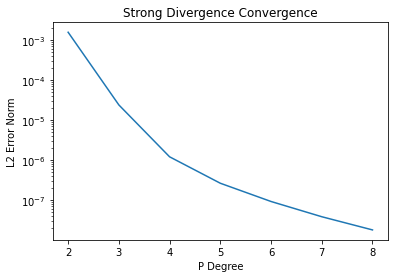

In [963]:
plt.plot(p_array, stg_l2)
plt.yscale('log')
plt.title('Strong Divergence Convergence')
plt.xlabel('P Degree')
plt.ylabel('L2 Error Norm')

Text(0, 0.5, 'L2 Error Norm')

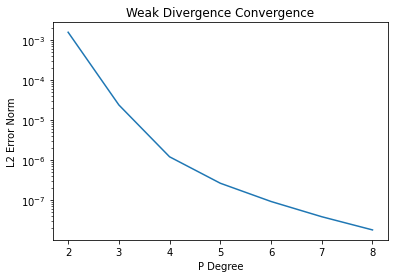

In [964]:
plt.plot(p_array, wk_l2)
plt.yscale('log')
plt.title('Weak Divergence Convergence')
plt.xlabel('P Degree')
plt.ylabel('L2 Error Norm')

### Weak gradient routine:

In [590]:
array_in = np.cos(map_spherical(map_cartesian(grid_file, ref_coords, GLL_points)[0])['lat'])

In [591]:
grad_array_in = -(np.sin(map_spherical(map_cartesian(grid_file, ref_coords, GLL_points)[0])['lat']))

In [30]:
det_J = xr.apply_ufunc(np.linalg.det,
                           d_rmap(grid_file, ref_coords, GLL_points).transpose("r_dim", "c_dim", 'n_face', 'x2', 'y2'),
                           input_core_dims=[["r_dim","c_dim"]], output_core_dims=[[]],
                           vectorize=True, dask="parallelized", 
                           output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
weights_2D_array = xr.DataArray(np.outer(quad_weights(GLL_points), quad_weights(GLL_points)),
                                coords = {'x2': np.arange(npts), 'y2' : np.arange(npts)}, dims = ['x2', 'y2'])
W_ij = (det_J) * weights_2D_array

In [33]:
# Note: The weak gradient returns a vector in physical coordinates; test functions are in the covariant basis 

def weak_grad(array_in, grid_file, ref_coords, GLL_points, npts, W_ij):
    return_array = np.zeros([grid_file.n_face, 2, npts, npts])
    comp_1 = xr.DataArray(np.eye(npts * npts, dtype=int).reshape(npts * npts, npts, npts), 
                               coords = {'test_func' : np.arange(npts * npts),
                                         'x2' : np.arange(len(GLL_points)), 'y2' : np.arange(len(GLL_points))}, dims = ['test_func', 'x2', 'y2'])
    comp_2 = xr.DataArray(np.zeros((npts * npts, npts, npts)), coords = {'test_func' : np.arange(npts * npts),
                                                                     'x2' : np.arange(len(GLL_points)), 'y2' : np.arange(len(GLL_points))}, dims = ['test_func', 'x2', 'y2'])
    i_comp = xr.concat([comp_1, comp_2], dim = 'c_dim').expand_dims(n_face = grid_file.n_face).assign_coords(n_face = np.arange(grid_file.n_face))
    j_comp = xr.concat([comp_2, comp_1], dim = 'c_dim').expand_dims(n_face = grid_file.n_face).assign_coords(n_face = np.arange(grid_file.n_face))
    
    # Convert from covariant to physical vec:
    d_inv_tran = xr.apply_ufunc(np.linalg.inv,
                    d_rmap(grid_file, ref_coords, GLL_points),
                    input_core_dims=[["c_dim","r_dim"]], output_core_dims=[["c_dim","r_dim"]],
                    vectorize=True, dask="parallelized", output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
    
    # Loop test functions:
    for i in np.arange(npts * npts):
        phys_vector_i = xr.apply_ufunc(np.matmul, d_inv_tran, i_comp.isel(test_func = i),
                                       input_core_dims=[["c_dim", "r_dim"], ["c_dim"]], output_core_dims=[["c_dim"]],
                                       vectorize=True, dask="parallelized", output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])

        phys_vector_j = xr.apply_ufunc(np.matmul, d_inv_tran, j_comp.isel(test_func = i),
                                       input_core_dims=[["c_dim", "r_dim"], ["c_dim"]], output_core_dims=[["c_dim"]],
                                       vectorize=True, dask="parallelized", output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
    
        row_i, col_i = np.where(comp_1.isel(test_func = i) == 1)
        div_array_i = stg_div(phys_vector_i.rename({'c_dim' : 'r_dim'}), grid_file, ref_coords, GLL_points, xr_D) * array_in
        div_array_j = stg_div(phys_vector_j.rename({'c_dim' : 'r_dim'}), grid_file, ref_coords, GLL_points, xr_D) * array_in
        quad_int_i = np.sum((div_array_i * W_ij).transpose('n_face', 'x2', 'y2'), axis = (1, 2))
        quad_int_j = np.sum((div_array_j * W_ij).transpose('n_face', 'x2', 'y2'), axis = (1, 2))
        
        return_array[:, 0, row_i[-1], col_i[-1]] = -quad_int_i
        return_array[:, 1, row_i[-1], col_i[-1]] = -quad_int_j
        
    # Convert from contravariant to physical coordinates:
    wk_grad_contra = xr.DataArray(return_array, coords = {'n_face' : np.arange(grid_file.n_face),
                                                'x2' : np.arange(len(GLL_points)), 'y2' : np.arange(len(GLL_points))}, 
                                  dims = ['n_face', 'r_dim', 'x2', 'y2']) 
    
    return(xr.apply_ufunc(np.matmul, 
                          d_rmap(grid_file, ref_coords, GLL_points).transpose('r_dim', 'c_dim', 'n_face', 'x2', 'y2'), wk_grad_contra,
                          input_core_dims=[["r_dim", "c_dim"], ["r_dim"]], output_core_dims=[["r_dim"]],
                          vectorize=True, dask="parallelized", output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype]))
    

In [594]:
wk_grad_comp_1 = weak_grad(array_in, grid_file, ref_coords, GLL_points, npts, W_ij).isel(r_dim = 1)
wk_grad_comp_0 = weak_grad(array_in, grid_file, ref_coords, GLL_points, npts, W_ij).isel(r_dim = 0)

In [595]:
proj_wk_grad_1 = proj_2D(wk_grad_comp_1 / W_ij, grid_file, ref_coords, GLL_points, npts, W_ij)
proj_wk_grad_0 = proj_2D(wk_grad_comp_0 / W_ij, grid_file, ref_coords, GLL_points, npts, W_ij) 

In [604]:
proj_stg_grad = proj_2D(stg_grad(array_in.assign_coords({'x2' : np.arange(npts), 'y2': np.arange(npts)}), 
                                 xr_D).isel(c_dim = 1), grid_file, ref_coords, GLL_points, npts, W_ij)

### Weak Laplacian:

In [34]:
def proj_wk_laplacian(array_in, xr_D, grid_file, ref_coords, GLL_points, npts, W_ij):
    stg_grad_array = stg_grad(array_in, xr_D)
    return(proj_2D(weak_div(stg_grad_array.isel(c_dim = 0), stg_grad_array.isel(c_dim = 1), 
                            grid_file, ref_coords, GLL_points, npts, xr_D, W_ij) / W_ij, grid_file, ref_coords, GLL_points, npts, W_ij))

### Solve Transport with CG:

In [35]:
zeros_array = xr.DataArray(np.zeros((grid_file.n_face, npts, npts)),
                           coords = {'n_face' : ('n_face', np.arange(grid_file.n_face)), 
                                     'x2' : (('x2'), np.arange(len(GLL_points))),
                                     'y2' : (('y2'), np.arange(len(GLL_points)))},
                           dims = ['n_face', 'x2', 'y2'])

ones_array = xr.DataArray(np.ones((grid_file.n_face, npts, npts)),
                           coords = {'n_face' : ('n_face', np.arange(grid_file.n_face)), 
                                     'x2' : (('x2'), np.arange(len(GLL_points))),
                                     'y2' : (('y2'), np.arange(len(GLL_points)))},
                           dims = ['n_face', 'x2', 'y2'])

In [36]:
u_comp = np.cos(map_spherical(map_cartesian(grid_file, ref_coords, GLL_points)[0])['lat'])
v_comp = xr.DataArray(np.zeros((grid_file.n_face, npts, npts)),
                      coords = {'n_face' : ('n_face', np.arange(grid_file.n_face)), 'GLL_points' : (('x2', 'y2'), np.arange(len(GLL_points) ** 2).reshape(len(GLL_points), len(GLL_points)))},
                      dims = ['n_face', 'x2', 'y2'])

In [37]:
# From Lauritzen 2012:

def init_gaussian(lat_array, lon_array):
    # Center at (x, y, z) = (1, 0, 0)
    t1 = ((np.cos(lat_array) * np.cos(lon_array)) + 1) ** 2
    t2 = (np.cos(lat_array) * np.sin(lon_array)) ** 2
    t3 = (np.sin(lat_array)) ** 2
    
    return(0.95 * np.exp(-5 * (t1 + t2 + t3)))

In [38]:
lat_array = map_spherical(map_cartesian(grid_file, ref_coords, GLL_points)[0])['lat']
lon_array = map_spherical(map_cartesian(grid_file, ref_coords, GLL_points)[0])['lon']

gauss_field = init_gaussian(lat_array, lon_array)

In [39]:
def weak_CG_2D_conserv(u, v, array_in, xr_D, grid_file, ref_coords, GLL_points, npts, W_ij):
    wk_div_flux = weak_div(u * array_in, v * array_in, grid_file, ref_coords, GLL_points, npts, xr_D, W_ij)
    return(proj_2D(wk_div_flux / W_ij, grid_file, ref_coords, GLL_points, npts, W_ij))

In [40]:
def stg_CG_2D_conserv(u, v, array_in, xr_D, grid_file, ref_coords, GLL_points, npts, W_ij):
    v_vector = xr.concat([u * array_in, v * array_in], dim = 'r_dim').assign_coords(x2 = np.arange(len(GLL_points)), 
                                                              y2 = np.arange(len(GLL_points)))
    stg_div_flux = stg_div(v_vector, grid_file, ref_coords, GLL_points, xr_D)
    return(proj_2D(stg_div_flux, grid_file, ref_coords, GLL_points, npts, W_ij))

In [41]:
def CG_2D_splfrm(u, v, array_in, xr_D, grid_file, ref_coords, GLL_points, npts, W_ij):
    v_vector = xr.concat([u, v], dim = 'r_dim').assign_coords(x2 = np.arange(len(GLL_points)), 
                                                              y2 = np.arange(len(GLL_points)))
    stg_div_flux = stg_div(v_vector * array_in, grid_file, ref_coords, GLL_points, xr_D)
    splfrm_term1 = array_in * stg_div(v_vector, grid_file, ref_coords, GLL_points, xr_D)
    splfrm_term2 = (v_vector * stg_grad(array_in.assign_coords(x2 = np.arange(len(GLL_points)), 
                                                               y2 = np.arange(len(GLL_points))), xr_D).rename({'c_dim' : 'r_dim'})).sum(dim = 'r_dim')
    return(proj_2D((0.5 * stg_div_flux) + (0.5) * (splfrm_term1 + splfrm_term2), grid_file, ref_coords, GLL_points, npts, W_ij))

In [234]:
CG_2D_splfrm(u_comp, v_comp, init_gaussian(lat_array, lon_array), 
             xr_D, grid_file, ref_coords, GLL_points, npts, W_ij)

<xarray.DataArray (n_face: 1350, x2: 4, y2: 4)>
array([[[-5.75296839e-07, -4.86009934e-07, -3.74104070e-07,
         -3.19824874e-07],
        [-6.22688414e-07, -5.28772503e-07, -4.10448676e-07,
         -3.52561056e-07],
        [-7.12834710e-07, -6.10927535e-07, -4.81052591e-07,
         -4.16546501e-07],
        [-7.78695231e-07, -6.72900250e-07, -5.34756418e-07,
         -4.65320493e-07]],

       [[-3.19824874e-07, -2.75753077e-07, -2.17608097e-07,
         -1.88634528e-07],
        [-3.52561056e-07, -3.05498332e-07, -2.42932189e-07,
         -2.11489228e-07],
        [-4.16546501e-07, -3.64002013e-07, -2.93256237e-07,
         -2.57164847e-07],
        [-4.65320493e-07, -4.08793668e-07, -3.32051993e-07,
         -2.92474779e-07]],

       [[-1.88634528e-07, -1.64601969e-07, -1.32185118e-07,
         -1.15608367e-07],
...
        [ 5.51910583e-02,  5.52502621e-02,  5.44814543e-02,
          5.35084394e-02]],

       [[ 1.11170316e-01,  1.08648651e-01,  1.03195852e-01,
          9.90833399e-02],
        [ 9.15474475e-02,  8.93829576e-02,  8.47728928e-02,
          8.13255435e-02],
        [ 6.60142666e-02,  6.43665523e-02,  6.09244666e-02,
          5.83835090e-02],
        [ 5.35084394e-02,  5.21415569e-02,  4.93136285e-02,
          4.72392329e-02]],

       [[ 9.90833399e-02,  9.42248608e-02,  8.56798051e-02,
          8.00368753e-02],
        [ 8.13255435e-02,  7.72957726e-02,  7.02321287e-02,
          6.56553993e-02],
        [ 5.83835090e-02,  5.54551927e-02,  5.03533858e-02,
          4.70223752e-02],
        [ 4.72392329e-02,  4.48666823e-02,  4.07436417e-02,
          3.80911526e-02]]])
Coordinates:
  * n_face      (n_face) int64 0 1 2 3 4 5 6 ... 1344 1345 1346 1347 1348 1349
    GLL_points  (x2, y2) int64 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
Dimensions without coordinates: x2, y2

In [ ]:
t_steps = 3
dt = 0.005
coeff = 1e5 / (6.371e6 ** 4)

init = init_gaussian(lat_array, lon_array)

for i in np.arange(0, t_steps, dt):
    # Half time step:
    init_mid = init - ((dt / 2) * (CG_2D_splfrm(u_comp, v_comp, init, xr_D, grid_file, 
                                                      ref_coords, GLL_points, npts, W_ij)))
    # Full time step:
    init_n = (init - ((dt) * CG_2D_splfrm(u_comp, v_comp, init_mid, xr_D, grid_file, 
                                                ref_coords, GLL_points, npts, W_ij))).assign_coords({'x2' : np.arange(npts), 'y2' : np.arange(npts)})
    
    # Apply hypervisocity after the full timestep:
    # visc_array = proj_wk_laplacian(init_n, xr_D, grid_file, ref_coords, GLL_points, npts, W_ij)
    # init_hypv = init_n - (coeff * proj_wk_laplacian(init_n, xr_D, grid_file, ref_coords, GLL_points, npts, W_ij))
    
    # Prepare for the next timestep:
    # init = init_hypv
    init = init_n
    
    print(i, end="\r")

### Plotting

In [1063]:
ds_grid = map_spherical(map_cartesian(grid_file, ref_coords, GLL_points)[0])
ds_grid['face_node_connectivity'] = grid_file.face_node_connectivity

In [1067]:
ds_grid.rename({'lat' : 'node_lat', 'lon' : 'node_lon'})

<xarray.Dataset>
Dimensions:                 (n_face: 5400, x2: 4, y2: 4, n_max_face_nodes: 4)
Coordinates:
  * n_face                  (n_face) int64 0 1 2 3 4 ... 5396 5397 5398 5399
    GLL_points              (x2, y2) int64 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
Dimensions without coordinates: x2, y2, n_max_face_nodes
Data variables:
    node_lat                (n_face, x2, y2) float64 -0.567 -0.5734 ... 0.6391
    node_lon                (n_face, x2, y2) float64 5.498 5.512 ... 2.318 2.304
    face_node_connectivity  (n_face, n_max_face_nodes) int64 0 8 356 ... 6 298

In [47]:
ds = xr.open_dataset('/home/hsingh/Downloads/2Dsph_ndiv_CGTransport_500tps.nc')['__xarray_dataarray_variable__']

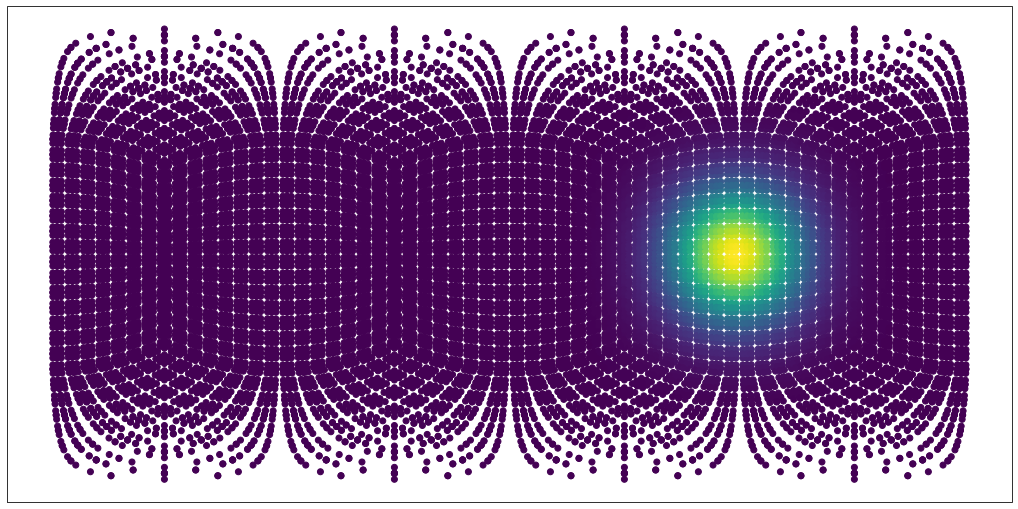

In [245]:
plt.figure(figsize=(18,10))
ax = plt.axes(projection=ccrs.PlateCarree())

sc = ax.scatter(lon_array.values.flatten(), lat_array.values.flatten(), 
                c = init.values.flatten(), cmap='viridis', transform=ccrs.PlateCarree())
# plt.colorbar(sc, ax=ax, label='Value')

In [246]:
sln_mass = np.sum(np.sum(((det_J) * weights_2D_array) * init, axis = (1, 2)))
sln_mass

<xarray.DataArray ()>
array(0.5969026)

In [247]:
init_mass = np.sum(np.sum(((det_J) * weights_2D_array) * init_gaussian(lat_array, lon_array), axis = (1, 2)))
init_mass

<xarray.DataArray ()>
array(0.5969026)

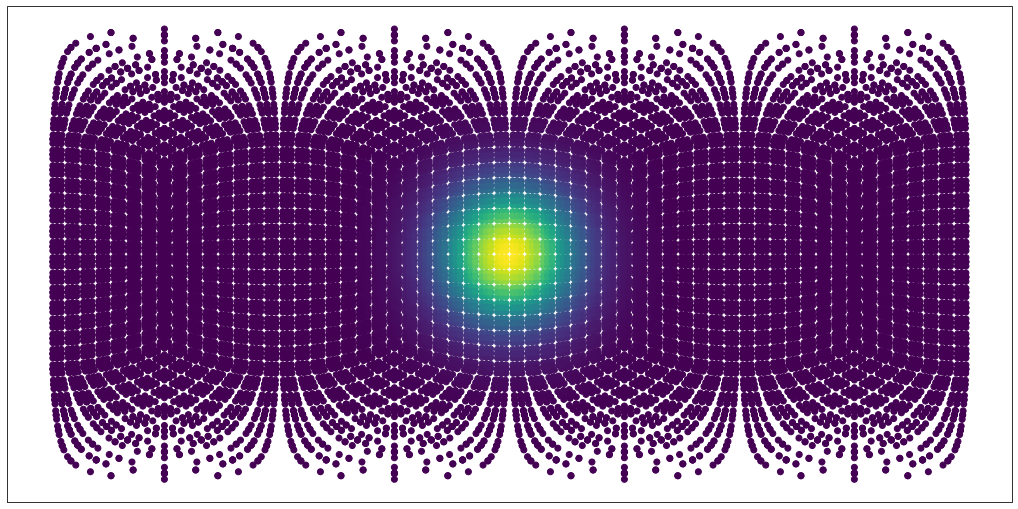

In [131]:
plt.figure(figsize=(18,10))
ax = plt.axes(projection=ccrs.PlateCarree())

sc = ax.scatter(lon_array.values.flatten(), lat_array.values.flatten(), 
                c=init_gaussian(lat_array, lon_array).values.flatten(), cmap='viridis', transform=ccrs.PlateCarree())
# plt.colorbar(sc, ax=ax, label='Value')

In [1138]:
#sln_tsteps_600.to_netcdf('2Dsph_ndiv_CGTransport_600tps.nc')